# Prodigy InfoTech - Task 05: Neural Style Transfer

## 📌 Objective
The objective of this task is to apply the artistic style of one image (e.g., a famous painting) to the semantic content of another image using **Neural Style Transfer (NST)**.

## 🔬 Scientific Foundations & Methodology
Based on the seminal paper by **Leon A. Gatys, Alexander S. Ecker, and Matthias Bethge (2015)** (*"A Neural Algorithm of Artistic Style"*):

1. **Content Representation**:
   - Deep convolutional neural networks (CNNs) trained on object classification develop internal representations that progressively separate image content from style.
   - Feature activations in higher layers capture high-level semantic layout and geometric arrangement rather than exact pixel values.
   - Content Loss at layer $l$ between content image $C$ and target image $G$:
     $$\mathcal{L}_{\text{content}}(C, G, l) = \frac{1}{2} \sum_{i, j} \left( F_{ij}^l(G) - F_{ij}^l(C) \right)^2$$

2. **Style Representation & Gram Matrix**:
   - Artistic style (colors, textures, brushstrokes) is captured through feature space correlations across feature channels, discarding spatial layout.
   - The **Gram Matrix** $G^l \in \mathbb{R}^{C \times C}$ at layer $l$ is the inner product of vectorized feature map activations:
     $$G_{ij}^l = \frac{1}{C \cdot H \cdot W} \sum_{k=1}^{H \cdot W} F_{ik}^l F_{jk}^l$$
   - Style Loss across selected layers $L_{style}$:
     $$\mathcal{L}_{\text{style}}(S, G) = \sum_{l \in L_{style}} w_l \cdot \frac{1}{4 N_l^2 M_l^2} \sum_{i, j} \left( G_{ij}^l(G) - G_{ij}^l(S) \right)^2$$

3. **Total Variation (TV) Regularization**:
   - Encourages spatial smoothness and eliminates high-frequency noise:
     $$\mathcal{L}_{\text{tv}}(G) = \sum_{i, j} \left( (G_{i+1, j} - G_{i, j})^2 + (G_{i, j+1} - G_{i, j})^2 \right)$$

4. **Composite Optimization Objective**:
   $$\mathcal{L}_{\text{total}}(G) = \alpha \mathcal{L}_{\text{content}} + \beta \mathcal{L}_{\text{style}} + \gamma \mathcal{L}_{\text{tv}}$$
   We directly optimize the pixel values of the target image $G$ using gradient descent with autograd.

In [1]:
import os
import io
import time
import copy
import requests
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models

# Device configuration & reproducibility
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)

print(f'PyTorch Version : {torch.__version__}')
print(f'Computation Device: {device}')

PyTorch Version : 2.12.0+cpu
Computation Device: cpu


In [2]:
# Standard ImageNet normalization statistics
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def load_image(image_input, max_size=200, shape=None):
    """
    Loads an image from a file path, URL, or PIL Image,
    resizes it, and transforms it into a normalized PyTorch tensor.
    """
    if isinstance(image_input, str):
        if image_input.startswith('http://') or image_input.startswith('https://'):
            resp = requests.get(image_input, timeout=10)
            image = Image.open(io.BytesIO(resp.content)).convert('RGB')
        else:
            image = Image.open(image_input).convert('RGB')
    elif isinstance(image_input, Image.Image):
        image = image_input.convert('RGB')
    else:
        raise TypeError("Expected file path, URL string, or PIL Image.")
        
    # Size calculation
    if shape is not None:
        size = shape
    else:
        # Maintain aspect ratio
        scale = max_size / max(image.size)
        size = (int(image.size[0] * scale), int(image.size[1] * scale))
        
    transform = transforms.Compose([
        transforms.Resize(size),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])
    
    tensor = transform(image).unsqueeze(0).to(device)
    return tensor

def im_convert(tensor):
    """
    Un-normalizes a PyTorch tensor and converts it into a displayable NumPy image [0, 1].
    """
    image = tensor.clone().detach().cpu().squeeze(0)
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    image = image * std + mean
    image = image.clamp(0.0, 1.0).permute(1, 2, 0).numpy()
    return image

print('Image preprocessing utilities successfully configured.')

Image preprocessing utilities successfully configured.


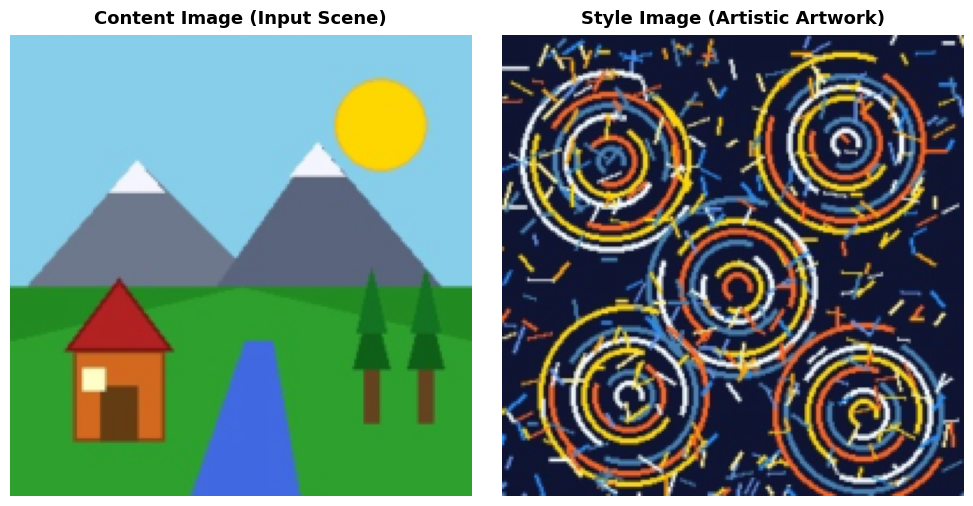

In [3]:
def ensure_sample_images():
    """
    Creates default high-contrast scenic content and artistic style samples
    if not already present on disk.
    """
    if not os.path.exists('content_sample.jpg') or not os.path.exists('style_sample.jpg'):
        size = 256
        # Content Image: Mountain Landscape with house & sun
        c_img = Image.new('RGB', (size, size), (135, 206, 235))
        d = ImageDraw.Draw(c_img)
        d.ellipse([180, 25, 230, 75], fill=(255, 215, 0), outline=(255, 180, 0))
        d.polygon([(0, 150), (70, 70), (150, 150)], fill=(110, 120, 140))
        d.polygon([(100, 160), (170, 60), (256, 160)], fill=(90, 100, 125))
        d.rectangle([0, 140, size, size], fill=(34, 139, 34))
        d.polygon([(100, 256), (130, 170), (145, 170), (160, 256)], fill=(65, 105, 225))
        d.rectangle([35, 175, 85, 225], fill=(210, 105, 30), outline=(139, 69, 19), width=2)
        d.polygon([(30, 175), (60, 135), (90, 175)], fill=(178, 34, 34), outline=(120, 20, 20), width=2)
        c_img.save('content_sample.jpg', quality=95)
        
        # Style Image: Van Gogh-style celestial swirls
        s_img = Image.new('RGB', (size, size), (15, 20, 50))
        ds = ImageDraw.Draw(s_img)
        palette = [(255, 215, 0), (255, 165, 0), (30, 144, 255), (70, 130, 180), (240, 248, 255)]
        for cx, cy in [(60, 70), (190, 60), (130, 140), (70, 200), (200, 210)]:
            for r in range(8, 55, 6):
                col = palette[(cx + r) % len(palette)]
                ds.arc([cx-r, cy-r, cx+r, cy+r], start=(r*15)%360, end=(r*15 + 260)%360, fill=col, width=3)
        s_img.save('style_sample.jpg', quality=95)
    
ensure_sample_images()

# Load both images at identical dimensions (200x200 for fast CPU processing)
IMG_SIZE = 200
content_tensor = load_image('content_sample.jpg', shape=(IMG_SIZE, IMG_SIZE))
style_tensor   = load_image('style_sample.jpg',   shape=(IMG_SIZE, IMG_SIZE))

# Display inputs side-by-side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(im_convert(content_tensor))
axes[0].set_title('Content Image (Input Scene)', fontsize=13, fontweight='bold', pad=8)
axes[0].axis('off')

axes[1].imshow(im_convert(style_tensor))
axes[1].set_title('Style Image (Artistic Artwork)', fontsize=13, fontweight='bold', pad=8)
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [4]:
def gram_matrix(tensor):
    """
    Computes the Gram Matrix of a batch of feature maps.
    G = (F * F^T) / (C * H * W)
    """
    b, c, h, w = tensor.size()
    features = tensor.view(b, c, h * w)
    # Batch matrix multiplication: (B, C, HW) x (B, HW, C) -> (B, C, C)
    gram = torch.bmm(features, features.transpose(1, 2))
    return gram / (c * h * w)

class NSTFeatureExtractor(nn.Module):
    """
    Extracts intermediate feature activations from a pre-trained backbone.
    Defaults to SqueezeNet 1.1 for lightweight, fast CPU execution (or VGG19).
    """
    def __init__(self, backbone='squeezenet', device='cpu'):
        super().__init__()
        self.backbone = backbone
        self.device = device
        
        if backbone == 'squeezenet':
            model = models.squeezenet1_1(weights=models.SqueezeNet1_1_Weights.DEFAULT).features
            self.content_layer = 'layer_3'
            self.style_layers = ['layer_1', 'layer_4', 'layer_6', 'layer_7']
        elif backbone == 'vgg19':
            model = models.vgg19(weights=models.VGG19_Weights.DEFAULT).features
            self.content_layer = 'layer_21'  # Conv4_2
            self.style_layers = ['layer_0', 'layer_5', 'layer_10', 'layer_19', 'layer_28']
        else:
            raise ValueError(f"Unsupported backbone: {backbone}")
            
        self.model = model.to(device).eval()
        # Freeze all backbone parameters so gradients are only applied to the image
        for param in self.model.parameters():
            param.requires_grad = False
            
    def forward(self, x):
        features = {}
        cur = x
        for idx, layer in enumerate(self.model):
            cur = layer(cur)
            layer_name = f'layer_{idx}'
            if layer_name == self.content_layer:
                features['content'] = cur
            if layer_name in self.style_layers:
                features[layer_name] = cur
        return features

extractor = NSTFeatureExtractor(backbone='squeezenet', device=device)
print('Feature Extractor instantiated with SqueezeNet 1.1 backbone.')
print(f'Content Layer: {extractor.content_layer}')
print(f'Style Layers  : {extractor.style_layers}')

Feature Extractor instantiated with SqueezeNet 1.1 backbone.
Content Layer: layer_3
Style Layers  : ['layer_1', 'layer_4', 'layer_6', 'layer_7']


In [5]:
def perform_neural_style_transfer(
    content_img, 
    style_img, 
    extractor, 
    num_steps=200, 
    content_weight=1.0, 
    style_weight=1500.0, 
    tv_weight=1e-4,
    lr=0.035,
    log_interval=25
):
    """
    Executes Neural Style Transfer optimization via Adam.
    Returns:
        target_image (tensor), history (dict), snapshots (list of (step, image_np))
    """
    # Pre-compute fixed target representations with torch.no_grad()
    with torch.no_grad():
        content_features = {k: v.clone() for k, v in extractor(content_img).items()}
        style_features   = extractor(style_img)
        style_grams      = {k: gram_matrix(v).clone() for k, v in style_features.items() if k.startswith('layer_')}
        
    # Assign layer weights for style balance
    num_style_layers = len(style_grams)
    style_layer_weights = {k: 1.0 / num_style_layers for k in style_grams.keys()}
    
    # Initialize target as clone of content image for fast, coherent convergence
    target = content_img.clone().requires_grad_(True)
    optimizer = optim.Adam([target], lr=lr)
    
    history = {'step': [], 'total_loss': [], 'content_loss': [], 'style_loss': []}
    snapshots = [(0, im_convert(target))]
    
    print(f'Starting Neural Style Transfer ({num_steps} Steps)...')
    start_time = time.time()
    
    for step in range(1, num_steps + 1):
        optimizer.zero_grad()
        target_features = extractor(target)
        
        # 1. Content Loss
        c_loss = torch.mean((target_features['content'] - content_features['content']) ** 2)
        
        # 2. Style Loss
        s_loss = 0.0
        for layer_k, weight in style_layer_weights.items():
            t_gram = gram_matrix(target_features[layer_k])
            s_gram = style_grams[layer_k]
            s_loss += weight * torch.mean((t_gram - s_gram) ** 2)
            
        # 3. Total Variation Regularization
        diff_h = target[:, :, 1:, :] - target[:, :, :-1, :]
        diff_w = target[:, :, :, 1:] - target[:, :, :, :-1]
        tv_loss = torch.mean(diff_h ** 2) + torch.mean(diff_w ** 2)
        
        total_loss = content_weight * c_loss + style_weight * s_loss + tv_weight * tv_loss
        total_loss.backward()
        optimizer.step()
        
        history['step'].append(step)
        history['total_loss'].append(total_loss.item())
        history['content_loss'].append(c_loss.item())
        history['style_loss'].append(s_loss.item())
        
        if step % log_interval == 0 or step == 1 or step == num_steps:
            snapshots.append((step, im_convert(target)))
            print(f'Step {step:3d}/{num_steps} | Total Loss: {total_loss.item():.4f} | Content: {c_loss.item():.4f} | Style: {s_loss.item():.4f}')
            
    elapsed = time.time() - start_time
    print(f'Optimization completed in {elapsed:.2f} seconds!')
    return target, history, snapshots

In [6]:
# Execute Style Transfer for 200 iterations
target_tensor, history, snapshots = perform_neural_style_transfer(
    content_img=content_tensor,
    style_img=style_tensor,
    extractor=extractor,
    num_steps=200,
    content_weight=1.0,
    style_weight=1500.0,
    tv_weight=1e-4,
    lr=0.035,
    log_interval=25
)

# Save final output image to disk
final_stylized_image = im_convert(target_tensor)
output_pil = Image.fromarray((final_stylized_image * 255).astype(np.uint8))
output_pil.save('stylized_output.png')
print('Final stylized image saved to stylized_output.png')

Starting Neural Style Transfer (200 Steps)...
Step   1/200 | Total Loss: 572.3986 | Content: 0.0000 | Style: 0.3816
Step  25/200 | Total Loss: 88.7675 | Content: 3.1641 | Style: 0.0571
Step  50/200 | Total Loss: 25.3891 | Content: 4.8352 | Style: 0.0137
Step  75/200 | Total Loss: 16.6436 | Content: 5.0843 | Style: 0.0077
Step 100/200 | Total Loss: 13.2711 | Content: 5.1805 | Style: 0.0054
Step 125/200 | Total Loss: 11.4921 | Content: 5.2297 | Style: 0.0042
Step 150/200 | Total Loss: 10.4028 | Content: 5.2503 | Style: 0.0034
Step 175/200 | Total Loss: 9.6595 | Content: 5.2509 | Style: 0.0029
Step 200/200 | Total Loss: 9.1178 | Content: 5.2425 | Style: 0.0026
Optimization completed in 11.85 seconds!
Final stylized image saved to stylized_output.png


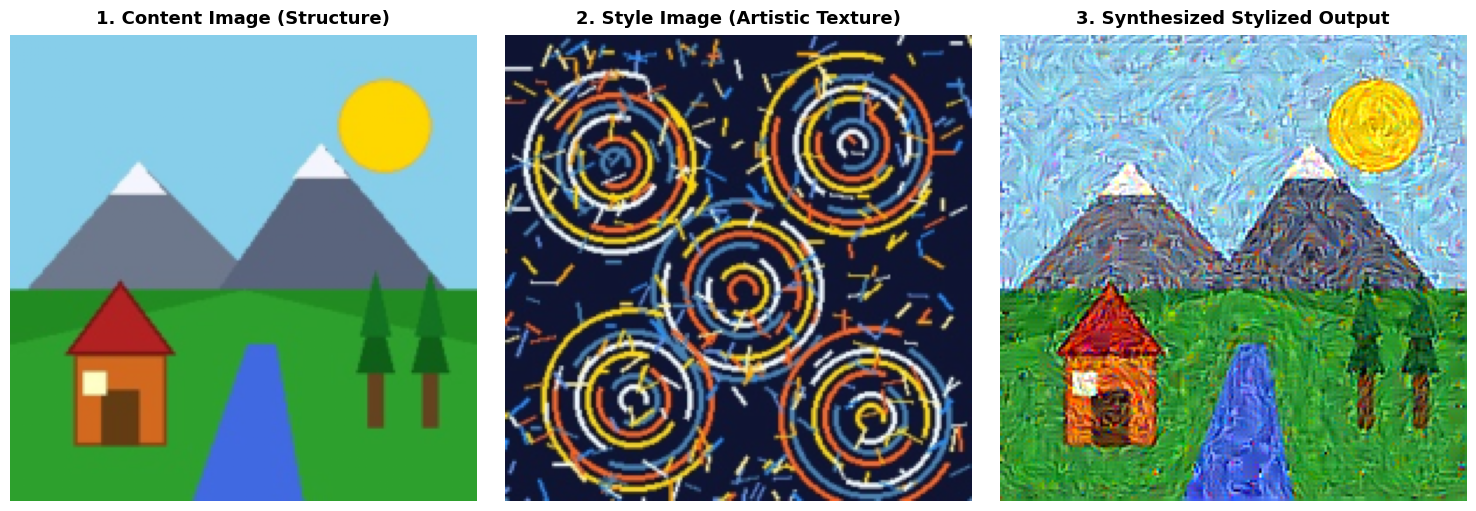

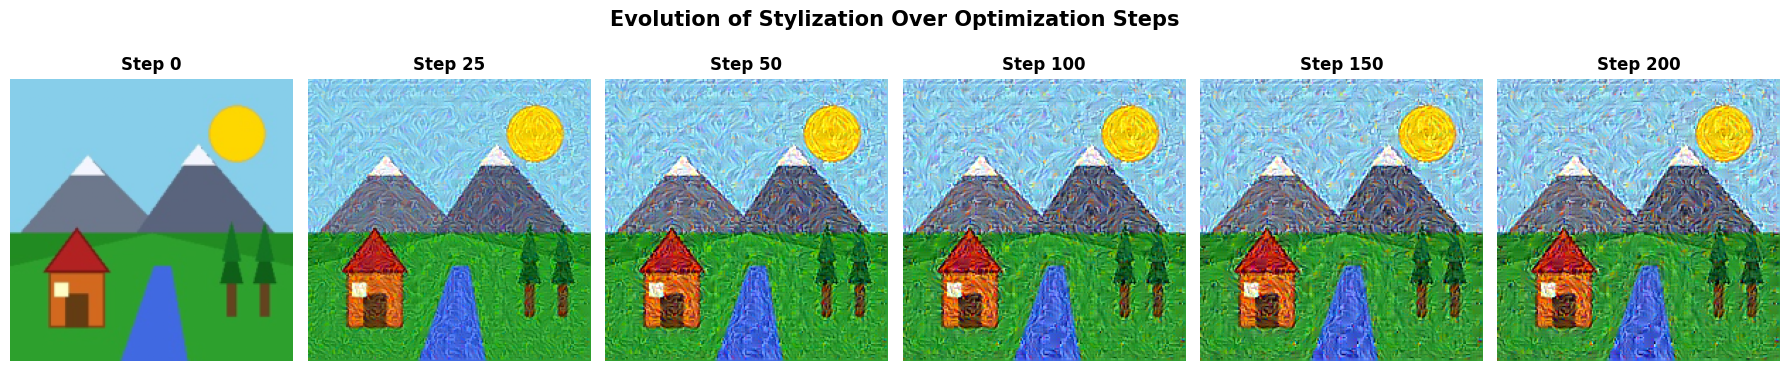

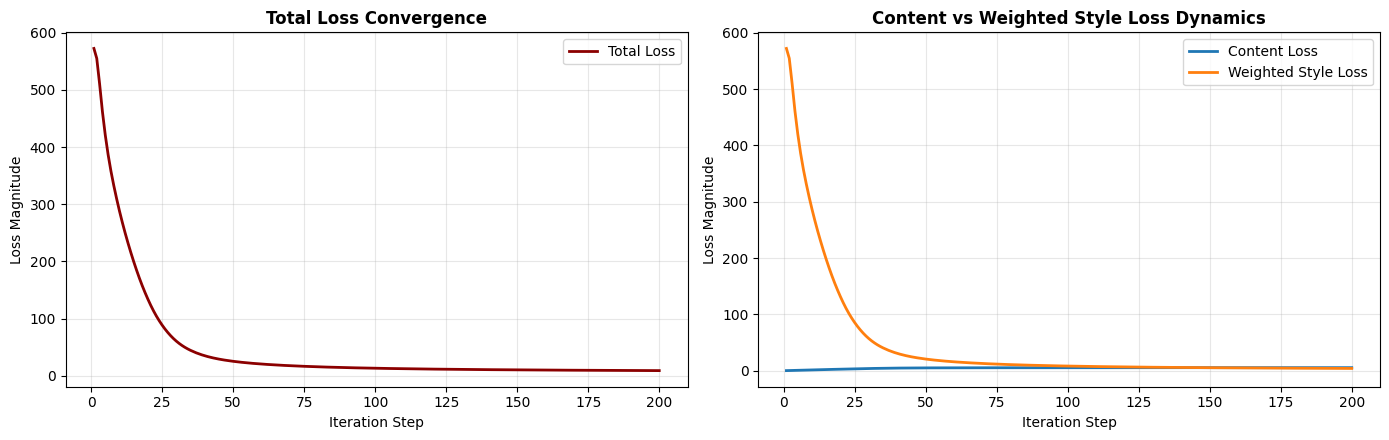

In [7]:
# 1. High-Quality Comparison Panel: [Content | Style | Stylized Result]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(im_convert(content_tensor))
axes[0].set_title('1. Content Image (Structure)', fontsize=13, fontweight='bold', pad=8)
axes[0].axis('off')

axes[1].imshow(im_convert(style_tensor))
axes[1].set_title('2. Style Image (Artistic Texture)', fontsize=13, fontweight='bold', pad=8)
axes[1].axis('off')

axes[2].imshow(final_stylized_image)
axes[2].set_title('3. Synthesized Stylized Output', fontsize=13, fontweight='bold', pad=8)
axes[2].axis('off')

plt.tight_layout()
plt.show()

# 2. Stylization Evolution Gallery
selected_snapshots = [s for s in snapshots if s[0] in [0, 25, 50, 100, 150, 200]]
fig, axes = plt.subplots(1, len(selected_snapshots), figsize=(18, 3.5))
for i, (step_num, snap_img) in enumerate(selected_snapshots):
    axes[i].imshow(snap_img)
    axes[i].set_title(f'Step {step_num}', fontsize=12, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Evolution of Stylization Over Optimization Steps', fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# 3. Optimization Convergence Loss Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

ax1.plot(history['step'], history['total_loss'], color='#8b0000', linewidth=2, label='Total Loss')
ax1.set_title('Total Loss Convergence', fontsize=12, fontweight='bold')
ax1.set_xlabel('Iteration Step')
ax1.set_ylabel('Loss Magnitude')
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(history['step'], history['content_loss'], color='#1f77b4', linewidth=2, label='Content Loss')
ax2.plot(history['step'], [s * 1500.0 for s in history['style_loss']], color='#ff7f0e', linewidth=2, label='Weighted Style Loss')
ax2.set_title('Content vs Weighted Style Loss Dynamics', fontsize=12, fontweight='bold')
ax2.set_xlabel('Iteration Step')
ax2.set_ylabel('Loss Magnitude')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

In [8]:
def transfer_style(content_source, style_source, steps=150, img_size=200, output_name='custom_stylized.png'):
    """
    All-in-one function to transfer artistic style between any two images (local files or URLs).
    """
    print(f'Loading images (size={img_size}x{img_size})...')
    c_t = load_image(content_source, shape=(img_size, img_size))
    s_t = load_image(style_source, shape=(img_size, img_size))
    
    res_t, _, _ = perform_neural_style_transfer(
        content_img=c_t,
        style_img=s_t,
        extractor=extractor,
        num_steps=steps,
        log_interval=50
    )
    
    res_np = im_convert(res_t)
    Image.fromarray((res_np * 255).astype(np.uint8)).save(output_name)
    print(f'Stylized result successfully saved to {output_name}!')
    
    # Quick display
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(res_np)
    ax.set_title(f'Stylized Output: {output_name}', fontsize=12, fontweight='bold')
    ax.axis('off')
    plt.show()
    return res_np

print('Stylization pipeline ready! You can invoke `transfer_style(content_path, style_path)` on your own images.')

Stylization pipeline ready! You can invoke `transfer_style(content_path, style_path)` on your own images.
